In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [48]:
## Defining Regression model 
class UnivariateLinearRegressor:
    def __init__(self,learning_rate=0.01,n_iters=1000):
        self.learning_rate=learning_rate
        self.n_iters=n_iters
        self.theta = None ## theta represents w and b
        self.MSE_loss_history = []
        self.theta_history = []

    def MSE_loss(self,y_pred,y):
        m = y.shape[0]
        loss = (1/(2*m)) * np.sum((y_pred-y)**2)
        return loss

    def gradient_descent(self,X,y,y_pred,theta):
        m = y.shape[0]
        ## computing gradients 
        gradient_0 = np.sum(y_pred - y) / m
        gradient_1 = np.sum(np.dot((y_pred - y).T, X[:, 1])) / m

        # Update Parameters
        theta[0] = theta[0] - self.learning_rate * gradient_0
        theta[1] = theta[1] - self.learning_rate * gradient_1

        return theta

    def fit(self,X:np.ndarray,y:np.ndarray) -> np.ndarray:
        """
        Reshape the input X and train the model

        Args:
            X (np.ndarray): Input feature matrix of dimension (n_samples,n_features)
            y (np.ndarray): Label matrix of dimension (n_samples,1)

        Returns:
            np.ndarray: Parameter: theta matrix of dimension (n_features+1,1)
        """
        ## add new dimension to X
        new_dimension = np.ones((X.shape[0],1))
        X = np.hstack((new_dimension,X))

        ## Initialize theta
        self.theta = np.zeros((X.shape[1],1))

        ## Training loop
        for i in range(self.n_iters):
            y_pred = np.dot(X,self.theta)
            
            ## loss compute
            loss = self.MSE_loss(y_pred,y)
            self.MSE_loss_history.append(loss)
            self.theta_history.append(self.theta)

            if i%100 == 0:
                print(f"Iteration {i}: MSE Loss = {loss}")

            ## use gradient descent
            self.theta = self.gradient_descent(X,y,y_pred,self.theta)

        return self.theta

    def predict(self,X:np.ndarray,theta:np.ndarray) -> np.ndarray:
        # this function assumes that X has been normalized

        new_dimension = np.ones((X.shape[0],1))
        X = np.hstack((new_dimension,X))
        predictions = np.dot(X,theta)

        return predictions


In [30]:
data = pd.read_csv('/home/lucifer/Documents/Tech_Manthan/Day-4/dataset/Salary_dataset.csv')
data

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [31]:
data.shape

(30, 3)

Dropping Unnamed: 0 column

In [32]:
data = data.drop('Unnamed: 0',axis=1)

In [33]:
data

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [34]:
## Separating the data into X and y
X = data['YearsExperience']
y = data['Salary']


In [35]:
X.shape

(30,)

In [36]:
y.shape

(30,)

In [37]:
type(X)

pandas.core.series.Series

In [38]:
X = X.values.reshape(-1,1)
y = y.values.reshape(-1,1)

In [39]:
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (30, 1)
Shape of y: (30, 1)


In [40]:
## Mean Normalization and Feature Scaling
X_mean = np.mean(X)
X_std = np.std(X)
X = (X-X_mean) / X_std

y_mean = np.mean(y)
y_std = np.std(y)
y = (y-y_mean) / y_std

In [43]:
X

array([[-1.51005294],
       [-1.43837321],
       [-1.36669348],
       [-1.18749416],
       [-1.11581443],
       [-0.86493538],
       [-0.82909552],
       [-0.75741579],
       [-0.75741579],
       [-0.57821647],
       [-0.50653674],
       [-0.47069688],
       [-0.47069688],
       [-0.43485702],
       [-0.29149756],
       [-0.1481381 ],
       [-0.07645838],
       [-0.00477865],
       [ 0.21026054],
       [ 0.2461004 ],
       [ 0.53281931],
       [ 0.6403389 ],
       [ 0.92705781],
       [ 1.03457741],
       [ 1.21377673],
       [ 1.32129632],
       [ 1.50049564],
       [ 1.5363355 ],
       [ 1.78721455],
       [ 1.85889428]])

In [44]:
y

array([[-1.36011263],
       [-1.10552744],
       [-1.419919  ],
       [-1.20495739],
       [-1.33978143],
       [-0.71830716],
       [-0.58815781],
       [-0.79981746],
       [-0.42881019],
       [-0.69801306],
       [-0.47433279],
       [-0.74976858],
       [-0.70662043],
       [-0.70201994],
       [-0.55250402],
       [-0.29921736],
       [-0.37004264],
       [ 0.26285865],
       [ 0.19885989],
       [ 0.66547573],
       [ 0.58377993],
       [ 0.82623317],
       [ 0.93861127],
       [ 1.40274136],
       [ 1.24020308],
       [ 1.09740238],
       [ 1.51986835],
       [ 1.3590738 ],
       [ 1.72102849],
       [ 1.70177321]])

In [63]:
## using train test split from scikit learn to split the dataset into train test set
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [64]:
X_train

array([[ 1.78721455],
       [ 1.21377673],
       [-0.47069688],
       [-1.51005294],
       [-1.11581443],
       [-0.07645838],
       [-0.86493538],
       [-0.43485702],
       [-0.47069688],
       [ 0.92705781],
       [-1.43837321],
       [-1.36669348],
       [ 1.32129632],
       [-1.18749416],
       [ 0.6403389 ],
       [ 1.50049564],
       [ 0.21026054],
       [ 1.85889428],
       [ 0.53281931],
       [-0.75741579],
       [-0.50653674],
       [-0.29149756],
       [ 0.2461004 ],
       [-0.82909552]])

In [65]:
X_test

array([[ 1.5363355 ],
       [-0.1481381 ],
       [ 1.03457741],
       [-0.00477865],
       [-0.75741579],
       [-0.57821647]])

In [70]:
model = UnivariateLinearRegressor(n_iters=500)
theta = model.fit(X_train,y_train)

Iteration 0: MSE Loss = 0.5282397699049977
Iteration 100: MSE Loss = 0.07788890461697734
Iteration 200: MSE Loss = 0.025595945294015227
Iteration 300: MSE Loss = 0.019474216422734024
Iteration 400: MSE Loss = 0.018750880708521857


In [71]:
theta

array([[-0.02370824],
       [ 0.97089178]])

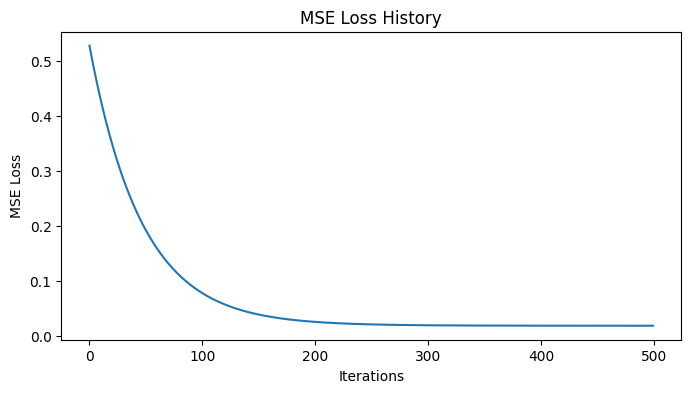

In [72]:
## Plotting loss history
loss_history = model.MSE_loss_history
plt.figure(figsize=(8,4))
sns.lineplot(loss_history)
plt.title("MSE Loss History")
plt.xlabel("Iterations")
plt.ylabel("MSE Loss")
plt.show()

In [73]:
## Plotting prediction vs target
predictions = model.predict(X_test,theta)

In [98]:
predictions

array([[ 1.46790726],
       [-0.16753431],
       [ 0.98075445],
       [-0.02834779],
       [-0.75907701],
       [-0.58509386]])

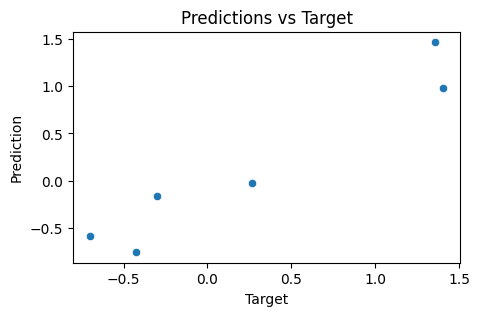

In [76]:
plt.figure(figsize=(5, 3))
sns.scatterplot(x=y_test[:, 0], y=predictions[:, 0])
plt.title("Predictions vs Target")
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.show()

In [77]:
y_pred = predictions * y_std + y_mean
y_true = y_test * y_std + y_mean

In [78]:
y_pred

array([[115569.45888333],
       [ 71488.33875929],
       [102438.9124634 ],
       [ 75239.9234507 ],
       [ 55544.10382081],
       [ 60233.58468507]])

In [79]:
y_true

array([[112636.],
       [ 67939.],
       [113813.],
       [ 83089.],
       [ 64446.],
       [ 57190.]])

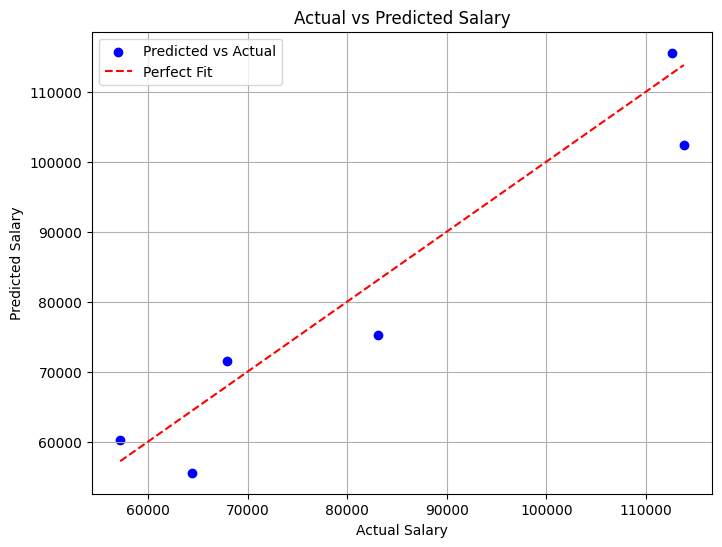

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(y_true,y_pred,color='blue',label='Predicted vs Actual')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], color='red', linestyle='--', label='Perfect Fit')
plt.xlabel('Actual Salary')
plt.ylabel('Predicted Salary')
plt.title('Actual vs Predicted Salary')
plt.legend()
plt.grid(True)
plt.show()

In [90]:
X_actual = X * X_std + X_mean
y_actual = y * y_std + y_mean

Text(0, 0.5, 'Salary')

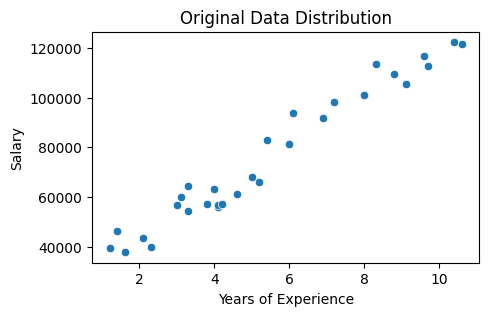

In [91]:
plt.figure(figsize=(5,3))
sns.scatterplot(x = X_actual.flatten(), y = y_actual.flatten())
plt.title("Original Data Distribution")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

#### Evaluating the model on different evaluation metrics

In [93]:
## MAE
def mean_absolute_error(y_true,y_pred):
    return np.mean(np.abs(y_true - y_pred))

In [94]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

In [95]:
##Root Mean Squared Error (RMSE)
def root_mean_squared_error(y_true,y_pred):
    return np.sqrt(mean_squared_error(y_true=y_true,y_pred=y_pred))

In [96]:
## R2 Score 
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

In [107]:
## Mean Absolute Percentage Error
def mean_absolute_percentage_error(y_true,y_pred):
    y_true,y_pred = np.array(y_true) , np.array(y_pred)

    non_zero_indices = y_true != 0
    y_true = y_true[non_zero_indices]
    y_pred = y_pred[non_zero_indices]
    mape_value = np.mean(np.abs((y_true-y_pred)/y_true)) * 100
    return mape_value

In [131]:
## Computing evaluation on different metrics
def evaluate(y_true,y_pred):
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)
    rmse = root_mean_squared_error(y_true,y_pred)
    r2 = r2_score(y_true,y_pred)
    mape = mean_absolute_percentage_error(y_true,y_pred)
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f} %")


In [132]:
evaluate(y_test,predictions)

Mean Absolute Error (MAE): 0.23
Mean Squared Error (MSE): 0.07
Root Mean Squared Error (RMSE): 0.26
R² Score: 0.90
Mean Absolute Percentage Error (MAPE): 47.68 %


In [126]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,root_mean_squared_error


lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [127]:
y_pred_lr = lr.predict(X_test)

In [128]:
y_pred_lr

array([[ 1.47613439],
       [-0.16712845],
       [ 0.98665184],
       [-0.0272763 ],
       [-0.76150012],
       [-0.58668493]])

In [129]:
# MSE
mse_sklearn = mean_squared_error(y_test, y_pred_lr)

# MAE
mae_sklearn = mean_absolute_error(y_test, y_pred_lr)

# R² Score
r2_sklearn = r2_score(y_test, y_pred_lr)

mape_value = mean_absolute_percentage_error(y_test,y_pred_lr)

rmse_sklearn = root_mean_squared_error(y_test,y_pred_lr)

In [130]:
print("Sklearn Linear Regression on Test Data:")
print(f"MAE: {mae_sklearn:.2f}")
print(f"MSE: {mse_sklearn:.2f}")
print(f"RMSE: {rmse_sklearn:.2f}")
print(f"R² Score: {r2_sklearn:.4f}")
print(f"MAPE: {mape_value:.2f}%")

Sklearn Linear Regression on Test Data:
MAE: 0.23
MSE: 0.07
RMSE: 0.26
R² Score: 0.9024
MAPE: 47.72%


As we can see that while viewing the evaluation metrics of both the model made from scratch and from sklearn , the evaluation result came out to similar and performance is similar.